# 反応拡散の基礎：Gray--Scottモデル

対応章：[反応拡散の基礎](../chapters/21_reaction_diffusion_basic.md)．

上から実行して，線形安定性，既知解による検証，有限振幅の初期条件からの模様生成を区別して学ぶ．ここでの濃度・時間・長さは無次元である．基準平衡点 `(u,v)=(1,0)` は線形安定であり，本計算の模様をその平衡点のチューリング不安定性とは呼ばない．

## ライブラリ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 線形化した空間モードの成長率

`J - q**2 * diag(Du, Dv)` の固有値の実部の最大値を計算する．`q` は角波数であり，波長は `2*pi/q` である．左は不安定帯域を持つ練習用の行列，右はGray--Scottの基準平衡点である．左図はGray--Scottの分散関係ではなく，最終的な非線形模様も予測していない．

In [2]:
def growth_rates(J, Du, Dv, q):
    q = np.asarray(q, dtype=float)
    matrices = np.asarray(J, dtype=float) - q[..., None, None]**2*np.diag([Du, Dv])
    return np.linalg.eigvals(matrices).real.max(axis=-1)

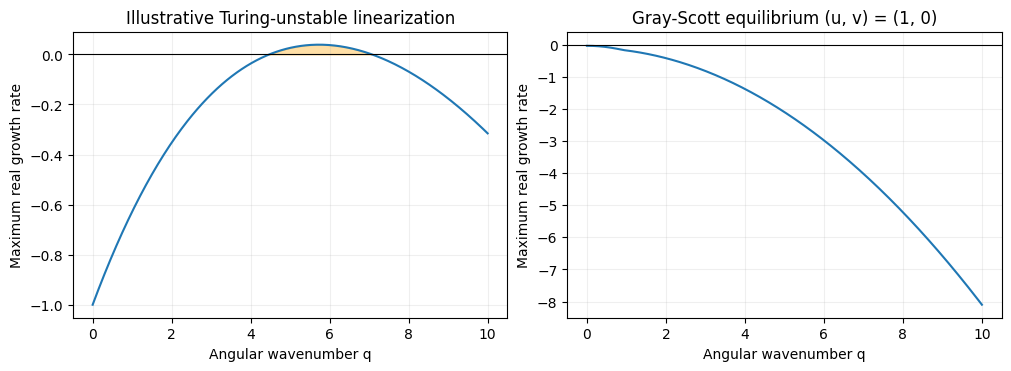

In [3]:
q = np.linspace(0, 10, 401)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
examples = [(np.array([[1, -2], [2, -3]]), 0.01, 0.1, 'Illustrative Turing-unstable linearization'),
            (np.diag([-0.035, -0.1]), 0.16, 0.08, 'Gray-Scott equilibrium (u, v) = (1, 0)')]
for ax, (J, du, dv, title) in zip(axes, examples):
    alpha = growth_rates(J, du, dv, q)
    ax.plot(q, alpha)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.fill_between(q, 0, alpha, where=alpha > 0, color='orange', alpha=0.35)
    ax.set(xlabel='Angular wavenumber q', ylabel='Maximum real growth rate', title=title)
    ax.grid(alpha=0.2)
plt.show()

## パラメータと格子

周期領域には両端を重複して置かないので `dx = LENGTH/N` となる．`DT` は希望する時間刻みであり，関数内で終了時刻をそろえるため少し小さくする場合がある．格子を変える検証では `LENGTH` と `T_END` を固定する．

In [4]:
Du, Dv = 0.16, 0.08
F_feed, k_kill = 0.035, 0.065
N, LENGTH, T_END, DT = 128, 128.0, 4000.0, 1.0
dx = LENGTH / N
print('diffusion CFL =', max(Du, Dv)*DT/dx**2, '; limit = 0.25')

diffusion CFL = 0.16 ; limit = 0.25


## 周期境界の5点差分ラプラシアン

In [5]:
def laplacian(Z, dx):
    return (np.roll(Z, 1, 0) + np.roll(Z, -1, 0)
            + np.roll(Z, 1, 1) + np.roll(Z, -1, 1) - 4*Z) / dx**2

## 非負の初期条件と同時更新

中央に滑らかな有限振幅の領域を置き，小さな空間変動を加える．初期分布は周期関数として定義しているので，同じseedなら格子を変えても同じ関数を標本化できる．`amplitude=0` なら基準平衡点である．

`gray_scott_step` は両成分の右辺を古い値から計算する．`gray_scott` は拡散の条件を検査し，負の濃度や非有限値が出たら停止する．この検査を通っても精度は別に調べる必要がある．戻り値には場だけでなく実際の刻みと保存時刻の診断値も含める．

In [6]:
def initial_fields(N, length, seed=0, amplitude=1.0):
    # 同じ連続的な周期関数を各格子で標本化する．濃度は非負．
    if not 0 <= amplitude <= 1:
        raise ValueError('amplitude must be between 0 and 1')
    x = np.arange(N) * length / N
    X, Y = np.meshgrid(x, x)
    distance = (np.sin(np.pi*(X-length/2)/length)**2
                + np.sin(np.pi*(Y-length/2)/length)**2) / (0.12*np.pi)**2
    patch = np.exp(-distance**3)
    phases = np.random.default_rng(seed).uniform(0, 2*np.pi, size=2)
    noise = 0.5*(np.sin(2*np.pi*(3*X+2*Y)/length + phases[0])
                 + np.cos(2*np.pi*(2*X-3*Y)/length + phases[1]))
    u = 1 - 0.5*amplitude*patch
    v = 0.25*amplitude*patch*(1 + 0.02*noise)
    return u, v


def gray_scott_step(u, v, Du, Dv, F, k, dx, dt):
    # 両方の右辺を更新前の u, v から評価する．
    uvv = u * v**2
    du = Du*laplacian(u, dx) - uvv + F*(1-u)
    dv = Dv*laplacian(v, dx) + uvv - (F+k)*v
    return u + dt*du, v + dt*dv


def gray_scott(N=128, t_end=4000.0, Du=0.16, Dv=0.08,
               F=0.035, k=0.065, dt=1.0, length=128.0, seed=0, initial=None):
    parameters = np.array([t_end, Du, Dv, F, k, dt, length], dtype=float)
    if not np.isfinite(parameters).all():
        raise ValueError('parameters must be finite')
    if not isinstance(N, (int, np.integer)) or N < 3:
        raise ValueError('N must be an integer >= 3')
    if min(t_end, Du, Dv, F, k) < 0 or dt <= 0 or length <= 0:
        raise ValueError('rates and t_end must be nonnegative; dt and length positive')
    dx = length / N
    steps = int(np.ceil(t_end / dt))
    actual_dt = t_end / steps if steps else dt
    cfl = max(Du, Dv)*actual_dt / dx**2
    if cfl > 0.25 + 1e-14:
        raise ValueError(f'diffusion CFL = {cfl:.4g} > 0.25; decrease dt')
    u, v = initial_fields(N, length, seed) if initial is None else initial
    u, v = np.array(u, dtype=float, copy=True), np.array(v, dtype=float, copy=True)
    if u.shape != (N, N) or v.shape != (N, N):
        raise ValueError('initial arrays must both have shape (N, N)')
    if not (np.isfinite(u).all() and np.isfinite(v).all()) or min(u.min(), v.min()) < 0:
        raise ValueError('initial concentrations must be finite and nonnegative')
    snapshots = [(0.0, v.copy())]
    diagnostics = []
    save_steps = {0, steps//2, steps}
    for step in range(steps + 1):
        if step in save_steps:
            diagnostics.append(dict(t=step*actual_dt, u_min=u.min(), u_max=u.max(),
                                    v_min=v.min(), v_max=v.max(),
                                    u_mean=u.mean(), v_mean=v.mean(), v_variance=v.var()))
            if step:
                snapshots.append((step*actual_dt, v.copy()))
        if step == steps:
            break
        u, v = gray_scott_step(u, v, Du, Dv, F, k, dx, actual_dt)
        if not (np.isfinite(u).all() and np.isfinite(v).all()):
            raise FloatingPointError(f'non-finite concentration at step {step+1}; decrease dt')
        if min(u.min(), v.min()) < 0:
            raise FloatingPointError(f'negative concentration at step {step+1}; decrease dt')
    return dict(u=u, v=v, dx=dx, dt=actual_dt, steps=steps, t_end=t_end,
                length=length, cfl=cfl, snapshots=snapshots, diagnostics=diagnostics)

## 既知解との照合

最初の表は一様場の反応ODEなので空間誤差を含まない．時間刻みを半分にしたときの誤差比が約2か確認する．次の表は周期的な余弦波の拡散であり，`dt` を `dx**2` に比例させる．格子間隔を半分にしたときの誤差比が約4で，平均値が保存されるか確認する．

In [7]:
# 一様な反応ODE：空間誤差なしで時間精度を調べる．
rows = []
for dt_test in [1.0, 0.5, 0.25]:
    result = gray_scott(N=8, length=8, t_end=20, dt=dt_test,
                        initial=(np.full((8, 8), 0.7), np.zeros((8, 8))))
    exact = 1 + (0.7-1)*np.exp(-0.035*20)
    rows.append([result['dt'], np.max(np.abs(result['u']-exact))])
time_errors = pd.DataFrame(rows, columns=['dt', 'max error'])
time_errors['previous/current error'] = time_errors['max error'].shift() / time_errors['max error']
display(time_errors)

# 拡散の既知解：L と終了時刻を固定し，dt を dx^2 に比例させる．
rows = []
length_test, end_test, diffusivity = 16.0, 2.0, 0.16
for n in [16, 32, 64]:
    dx_test = length_test / n
    X = np.tile(np.arange(n)*dx_test, (n, 1))
    u0 = 1 + 0.1*np.cos(2*np.pi*X/length_test)
    result = gray_scott(N=n, length=length_test, t_end=end_test,
                        Du=diffusivity, Dv=0, F=0, k=0, dt=0.2*dx_test**2,
                        initial=(u0, np.zeros_like(u0)))
    exact = 1 + 0.1*np.exp(-diffusivity*(2*np.pi/length_test)**2*end_test)*np.cos(2*np.pi*X/length_test)
    rows.append([n, dx_test, result['dt'], np.max(np.abs(result['u']-exact)),
                 abs(result['u'].mean()-u0.mean())])
space_errors = pd.DataFrame(rows, columns=['N', 'dx', 'dt', 'max error', 'mean drift'])
space_errors['previous/current error'] = space_errors['max error'].shift()/space_errors['max error']
display(space_errors)

,dt,max error,previous/current error
0,1.00,0.001857,NaN
1,0.50,0.000920,2.017597
2,0.25,0.000458,2.008700


,N,dx,dt,max error,mean drift,previous/current error
0,16,1.00,0.2000,0.000049,0.000000e+00,NaN
1,32,0.50,0.0500,0.000012,0.000000e+00,3.997561
2,64,0.25,0.0125,0.000003,2.220446e-16,3.999409


## 有限振幅の領域から時間発展させる

In [8]:
baseline = gray_scott(N=N, length=LENGTH, t_end=T_END, dt=DT,
                      Du=Du, Dv=Dv, F=F_feed, k=k_kill, seed=0)
sustained = gray_scott(N=N, length=LENGTH, t_end=T_END, dt=DT,
                       Du=Du, Dv=Dv, F=0.055, k=0.062, seed=0)
u, v = baseline['u'], baseline['v']
evolutions = [(F_feed, k_kill, baseline), (0.055, 0.062, sustained)]
display(pd.concat([pd.DataFrame(result['diagnostics']).assign(F=F, k=k)
                   for F, k, result in evolutions], ignore_index=True))

,t,u_min,u_max,v_min,v_max,u_mean,v_mean,v_variance,F,k
0,0.0,0.500000,1.0,0.000000e+00,2.540349e-01,0.979023,1.051718e-02,1.969128e-03,0.035,0.065
1,2000.0,1.000000,1.0,1.701867e-93,1.436902e-89,1.000000,2.260386e-90,1.126646e-179,0.035,0.065
2,4000.0,1.000000,1.0,4.247361e-183,2.361216e-181,1.000000,6.905601e-182,0.000000e+00,0.035,0.065
3,0.0,0.500000,1.0,0.000000e+00,2.540349e-01,0.979023,1.051718e-02,1.969128e-03,0.055,0.062
4,2000.0,0.295976,1.0,8.969111e-35,4.229821e-01,0.943267,2.686032e-02,7.052971e-03,0.055,0.062
5,4000.0,0.296280,1.0,1.582459e-25,4.178684e-01,0.828487,8.104412e-02,1.678977e-02,0.055,0.062


## 濃度場の時間変化

共通の色範囲で，初期分布，中間時刻，終了時刻を比べる．上段の設定では今回の初期分布から濃度差が減衰し，下段の設定では模様が残る．有限振幅を与えたからといって必ず模様が残るわけではない．色は `v` の濃度であって写真の体色ではない．どちらも有限時刻の結果であり，定常性は別途確認する．

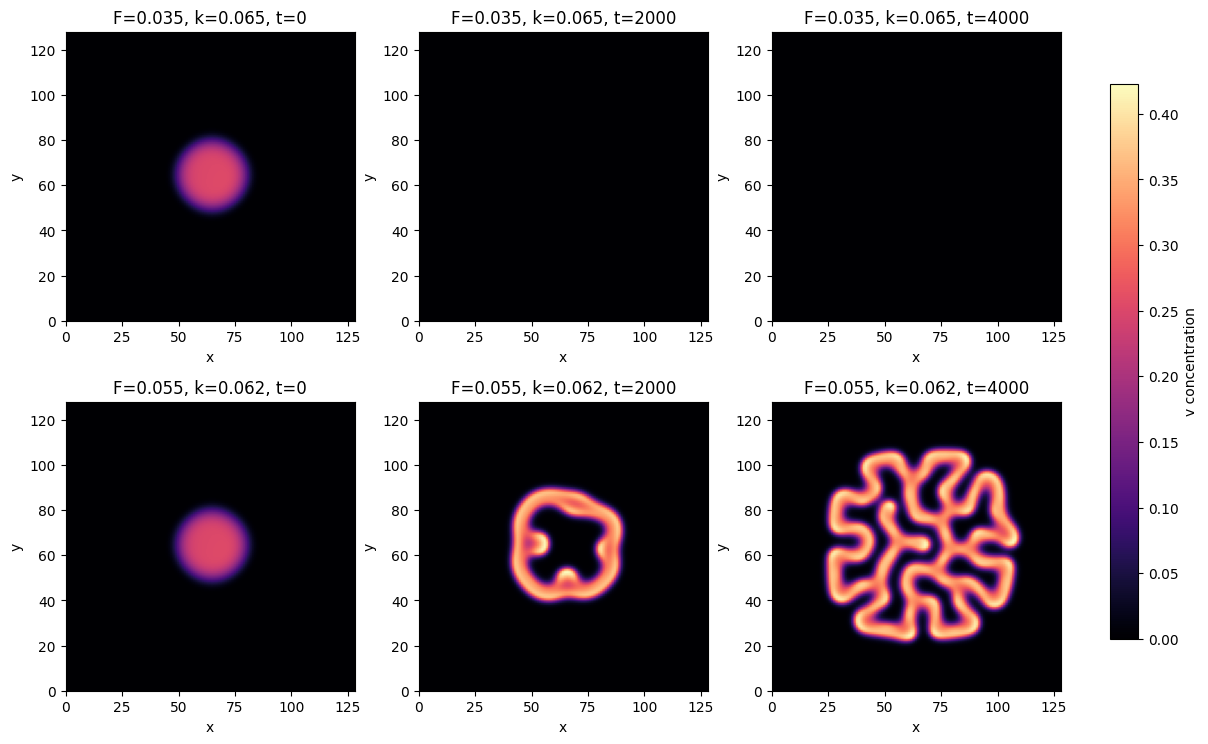

In [9]:
vmax = max(field.max() for _, _, result in evolutions for _, field in result['snapshots'])
fig, axes = plt.subplots(2, 3, figsize=(12, 7.4), constrained_layout=True)
for row, (F, k, result) in enumerate(evolutions):
    for ax, (time, field) in zip(axes[row], result['snapshots']):
        im = ax.imshow(field, origin='lower', extent=[0, LENGTH, 0, LENGTH],
                       cmap='magma', vmin=0, vmax=vmax)
        ax.set(title=f'F={F}, k={k}, t={time:g}', xlabel='x', ylabel='y')
fig.colorbar(im, ax=axes.ravel().tolist(), label='v concentration', shrink=0.8)
plt.show()

## Fとkを変えた比較

3条件とも領域長80，80×80格子，終了時刻3500，同じseedで計算する．上の基準計算とは領域が違うので，格子収束の比較ではない．各画像の最大値で個別に色を伸縮せず，共通のカラーバーを用いる．

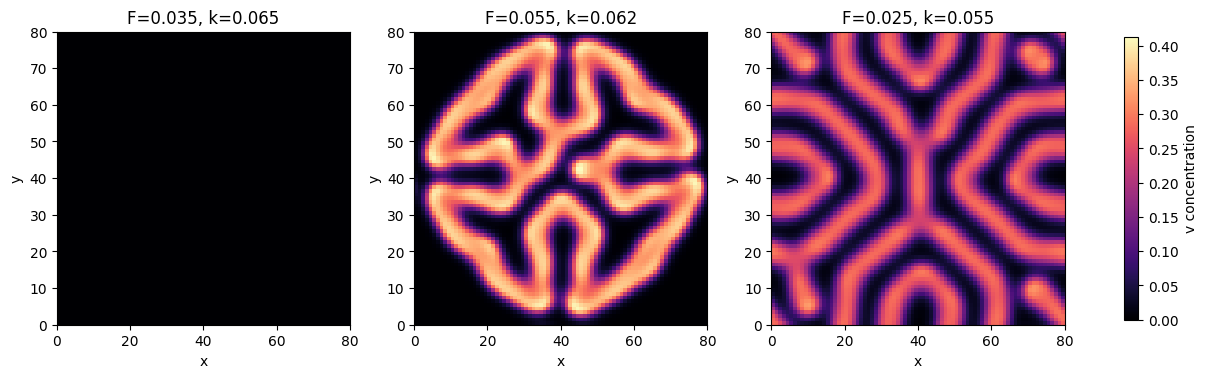

,F,k,area_fraction,variance,v_min,v_max
0,0.035,0.065,0.000000,7.225985e-317,1.459829e-158,4.827076e-158
1,0.055,0.062,0.398438,2.042245e-02,1.216170e-11,4.130754e-01
2,0.025,0.055,0.396875,9.074407e-03,5.632077e-03,3.279381e-01


In [10]:
params = [(0.035, 0.065), (0.055, 0.062), (0.025, 0.055)]
comparison = [gray_scott(N=80, length=80, t_end=3500, dt=1,
                         Du=Du, Dv=Dv, F=F, k=k, seed=1) for F, k in params]
vmax = max(result['v'].max() for result in comparison)
fig, axes = plt.subplots(1, len(params), figsize=(12, 3.8), constrained_layout=True)
for ax, (F, k), result in zip(axes, params, comparison):
    im = ax.imshow(result['v'], origin='lower', extent=[0, 80, 0, 80],
                   cmap='magma', vmin=0, vmax=vmax)
    ax.set(title=f'F={F}, k={k}', xlabel='x', ylabel='y')
fig.colorbar(im, ax=axes.tolist(), label='v concentration', shrink=0.8)
plt.show()
display(pd.DataFrame([dict(F=F, k=k, area_fraction=np.mean(r['v'] >= 0.2),
                           variance=r['v'].var(), v_min=r['v'].min(), v_max=r['v'].max())
                      for (F, k), r in zip(params, comparison)]))

## 課題：実装と検証

1. `scan_gray_scott(params, seed)` を作り，各 `(F, k)` の最終画像と `mean(v >= 0.2)` を保存する．領域長，格子，終了時刻，時間刻み，初期分布は共通にする．
2. `plot_gray_scott_scan(results)` を作り，共通の色範囲とカラーバーで画像を比較する．タイトルに `F`, `k`, 面積比を入れ，1条件だけでも動くようにする．
3. `diffusion_ratio_sweep(Dv_values)` を作り，濃度の平均・分散・面積比を表にする．分散は不均一さであり，波長ではないことを説明する．細かさは22章の波長関数を検証してから追加する．
4. `time_convergence(dts)` を作り，一様な初期値 `u=0.7, v=0` の厳密解と同じ終了時刻で比較する．最大誤差と誤差比を表示する．
5. 面積比と分散が近くても異なる模様を区別できるか，図と数値を対応させて考察する．複数seedや保存時刻でも結論が変わるかを確かめる．

In [11]:
# scan_gray_scott, plot_gray_scott_scan, diffusion_ratio_sweep,
# time_convergence を実装する．
# まず短い終了時刻で動作を確認し，研究に使う条件を別途検証する．